# EU Cohesion Funds → Gmina-Level Panel Dataset
---

**Project:** Geography of Discontent — LSE Policy Paper  
**Pipeline:** Consolidates 2007-2013, 2014-2020, 2021-2027 project lists into one gmina × year panel

### Pipeline Overview

| Step | Description | Decision Code |
|------|-------------|---------------|
| 1 | Read raw Excel project lists | — |
| 2 | Rename columns to common schema | — |
| 3 | Filter out non-cohesion funds | D5 |
| 4 | Remove national-level projects ("Cały Kraj") | D1 |
| 5 | Parse & explode multi-location projects | D2 |
| 6 | Match to TERYT codes (3-tier) | D6 |
| 7 | Distribute funding over time (quarterly) | D3 |
| 8 | Disaggregate powiat-only matches to gminas | D4 |
| 9 | Aggregate to gmina × year panel | — |
| 10 | Combine all periods + per-capita rates | D7 |

All decisions are logged with row counts and PLN amounts in `pipeline_decision_log.csv`.

## 0. Configuration
**Update all paths below to match your local directory structure.**

In [1]:
# =============================================================================
# CONFIGURATION — UPDATE THESE PATHS
# =============================================================================

import os

# Root of your repo
REPO_ROOT = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo"

config = {
    # TERYT master lookup
    'PATH_TERYT': os.path.join(REPO_ROOT, r"data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx"),

    # GMINA REVENUE WEIGHT
    # 'PATH_WEIGHTS': r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\code\processing\UE_funds_processing\revenue_weight_table_gmina_year.csv",
    # POPULATION WEIGHT
    'PATH_WEIGHTS': r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\code\processing\UE_funds_processing\population_weight_table_gmina_year.csv",
    'DISAGG_METHOD': 'weighted',
    
    # 2007-2013: Two Excel files (POKL + INNE)
    'PATH_200713_POKL': os.path.join(REPO_ROOT, r"data\inputs\3. treatment\_target_excels\Umowy_wszystko_POKL_30_06_2018.xls"),
    'PATH_200713_INNE': os.path.join(REPO_ROOT, r"data\inputs\3. treatment\_target_excels\Umowy_wszystko_INNE_30_06_2018.xls"),
    
    # 2014-2020: Single Excel
    'PATH_201420': os.path.join(REPO_ROOT, r"data\inputs\3. treatment\_target_excels\Lista_projektow_FE_2014_2020_04012026.xlsx"),
    
    # 2021-2027: Single Excel
    'PATH_202127': os.path.join(REPO_ROOT, r"data\inputs\3. treatment\_target_excels\Lista_projektow_FE_2021_2027_01022026.xlsx"),
    
    # Output directory
    'OUTPUT_DIR': os.path.join(REPO_ROOT, r"data\clean\treatment\eu_flows\final"),
    
    # Population data (from BDL download) — set to None if not yet available
    'PATH_POPULATION': None,
}

print("Path verification:")
for key, path in config.items():
    if path is None:
        print(f"  {key}: [SKIPPED - None]")
    elif key == 'DISAGG_METHOD':
        print(f"  {key}: {path}")
    elif os.path.exists(path):
        print(f"  ✓ {key}")
    else:
        print(f"  ✗ {key}: NOT FOUND → {path}")

Path verification:
  ✓ PATH_TERYT
  ✓ PATH_WEIGHTS
  DISAGG_METHOD: weighted
  ✓ PATH_200713_POKL
  ✓ PATH_200713_INNE
  ✓ PATH_201420
  ✓ PATH_202127
  ✓ OUTPUT_DIR
  PATH_POPULATION: [SKIPPED - None]


## 1. Import Pipeline

Make sure `eu_funds_pipeline.py` is in the same directory as this notebook (or on your Python path).

In [2]:
# If the pipeline file is in the same directory:
from eu_funds_pipeline import EUFundsPipeline, DecisionLog

# If it's elsewhere, uncomment and adjust:
# import sys
# sys.path.insert(0, r"path\to\code\directory")
# from eu_funds_pipeline import EUFundsPipeline

pipeline = EUFundsPipeline(config)
method = config.get('DISAGG_METHOD', 'equal')
print(f"Pipeline initialised.")
print(f"Disaggregation method: {'Revenue-weighted (D4w)' if method == 'weighted' else 'Equal split (D4)'}")

Pipeline initialised.
Disaggregation method: Revenue-weighted (D4w)


## 2. Build TERYT Lookup

Constructs three lookup dictionaries from the TERYT master register:
1. **Primary:** (voivodeship, powiat, gmina) → TERYT 7-digit code
2. **Fallback:** (voivodeship, gmina) → TERYT 7-digit code *(only if unambiguous)*
3. **Powiat:** (voivodeship, powiat) → TERYT 4-digit powiat code

Also builds the powiat → gmina hierarchy for disaggregation in Step 8.

In [3]:
pipeline.build_lookup()

19:09:31 [INFO] Building TERYT lookup from: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx
19:09:34 [INFO] TERYT lookup: 2339 primary, 2151 fallback, 381 powiat, 381 hierarchy entries
19:09:34 [INFO] Loaded weight table: 62,025 rows


## 3. Process 2007-2013

**Source:** Umowy_wszystko_POKL + Umowy_wszystko_INNE (KSI SIMIK)  
**Location format:** Separate columns (Województwo, Powiat, Gmina)  
**Fund filter:** All funds included  
**Notes:** Oldest period. Some projects have `project_place` with pipe-separated format.

In [4]:
panel_0713 = pipeline.process_200713()

if panel_0713 is not None:
    print(f"\n--- 2007-2013 Summary ---")
    print(f"Rows: {len(panel_0713):,}")
    print(f"Gminas: {panel_0713['gmina_id'].nunique():,}")
    print(f"Years: {sorted(panel_0713['Year'].unique())}")
    print(f"Total EU subsidy: {panel_0713['EU_subsidy_PLN'].sum():,.0f} PLN")
    display(panel_0713.head())


19:09:34 [INFO] ============================================================
19:09:34 [INFO] PROCESSING 2007-2013
19:09:34 [INFO] ============================================================
19:09:34 [INFO] Reading: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\_target_excels\Umowy_wszystko_POKL_30_06_2018.xls
19:09:44 [INFO] Reading: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\_target_excels\Umowy_wszystko_INNE_30_06_2018.xls
19:09:54 [INFO] Raw rows: 150,551
19:09:55 [INFO] [D1_EXCLUDE_NATIONAL] Removed 'Cały Kraj' projects (2007-2013) | rows: 150,551 → 148,116 (Δ-2,435) | PLN affected: 9,176,630,778
19:09:55 [INFO] Assigning geo IDs to 148,116 rows...
19:10:42 [INFO] Match results: gmina=104,837 (70.8%) | powiat_only=22,838 (15.4%) | unmatched=20,441 (13.8%)
19:10:42 [INFO] [D6_TERYT_MATCH] Geo matching (2007-2013): gmina=104837, powiat_

Columns with 'dat' or 'date': ['signing_date', 'creation_date_KSI_SIMIK_07_12', 'start_date', 'end_date']


19:10:44 [INFO] Temporal distribution: 147,846 distributable, 270 lump-sum
19:11:24 [INFO] [D3_TEMPORAL_DIST] Temporal distribution (2007-2013): 147846 distributed + 270 lump-sum | rows: 148,116 → 398,570 (Δ+250,454)
19:11:25 [INFO] Using WEIGHTED disaggregation for 2007-2013
19:11:25 [INFO] Weighted disaggregation: 55,669 powiat-only rows
19:11:27 [INFO]   Disaggregated 55,669 → 378,085 rows (total: 720,986)
19:11:27 [INFO] [D4_POWIAT_DISAGG_WEIGHTED] Weighted disaggregation (2007-2013): 55669 powiat rows → 378085 gmina rows | rows: 398,570 → 720,986 (Δ+322,416)


DEBUG: 0201011 rows after disagg: 110
Sample gmina_ids: ['2416021' '0663011' '0206021' '3201022' '1465011' '0208072' '0265011'
 '0264011' '1463011' '0207022']
ID lengths: {7: 662791}
Unique gmina_ids: 2481


19:11:33 [INFO] Panel (2007-2013): 22,409 rows, 2,481 gminas, years 2007-2018



--- 2007-2013 Summary ---
Rows: 22,409
Gminas: 2,481
Years: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Total EU subsidy: 183,448,100,642 PLN


,voivodeship_id,powiat_id,gmina_id,Year,EU_subsidy_PLN,total_value_PLN,subsidy_PLN,eligible_expenses_PLN,programming_period
0,02,0201,0201011,2008,9.044750e+05,1.066322e+06,1.029491e+06,1.066322e+06,2007-2013
1,02,0201,0201011,2009,1.191038e+06,1.403451e+06,1.366690e+06,1.403451e+06,2007-2013
2,02,0201,0201011,2010,1.526170e+06,1.797720e+06,1.763216e+06,1.797720e+06,2007-2013
3,02,0201,0201011,2011,1.455499e+06,1.714576e+06,1.680093e+06,1.714576e+06,2007-2013
4,02,0201,0201011,2012,1.389168e+06,1.636540e+06,1.602064e+06,1.636540e+06,2007-2013


In [5]:
# Diagnostic: check gmina_id format
if panel_0713 is not None:
    ids = panel_0713['gmina_id'].astype(str)
    ids_base = ids.str[:6]
    print(f"Unique 7-digit gmina_ids: {ids.nunique()}")
    print(f"Unique 6-digit base codes: {ids_base.nunique()}")
    print(f"Difference (urban/rural splits): {ids.nunique() - ids_base.nunique()}")
    
    from collections import Counter
    base_counts = Counter(ids_base)
    dupes = {k: v for k, v in base_counts.items() if v > 1}
    print(f"\nGminas with urban/rural split: {len(dupes)}")
    for base in list(dupes.keys())[:5]:
        variants = ids[ids_base == base].unique()
        print(f"  {base}: {variants}")

Unique 7-digit gmina_ids: 2481
Unique 6-digit base codes: 2481
Difference (urban/rural splits): 0

Gminas with urban/rural split: 2481
  020101: ['0201011']
  020102: ['0201022']
  020103: ['0201032']
  020104: ['0201043']
  020105: ['0201052']


In [6]:
# VALIDATION: check all 16 voivodeships are present
if panel_0713 is not None:
    woj_check = panel_0713['gmina_id'].astype(str).str.zfill(7).str[:2].unique()
    expected = {'02','04','06','08','10','12','14','16','18','20','22','24','26','28','30','32'}
    missing = expected - set(woj_check)
    if missing:
        print(f"⚠️ MISSING VOIVODESHIPS: {missing}")
    else:
        print(f"✓ All 16 voivodeships present")

✓ All 16 voivodeships present


## 4. Process 2014-2020

**Source:** Lista_projektow_FE_2014_2020 (SL2014 / dane.gov.pl)  
**Location format:** `WOJ.: X, POW.: Y` (no gmina in location string)  
**Fund filter:** Excludes BAR (Pomoc Techniczna)  
**Notes:** Header row = 2 (row 3 in Excel). Bilingual column names stripped.

In [7]:
panel_1420 = pipeline.process_201420()

if panel_1420 is not None:
    print(f"\n--- 2014-2020 Summary ---")
    print(f"Rows: {len(panel_1420):,}")
    print(f"Gminas: {panel_1420['gmina_id'].nunique():,}")
    print(f"Years: {sorted(panel_1420['Year'].unique())}")
    fin_col = 'EU_subsidy_PLN' if 'EU_subsidy_PLN' in panel_1420.columns else panel_1420.select_dtypes('number').columns[0]
    print(f"Total EU subsidy: {panel_1420[fin_col].sum():,.0f} PLN ({fin_col})")

19:11:34 [INFO] ============================================================
19:11:34 [INFO] PROCESSING 2014-2020
19:11:34 [INFO] ============================================================
19:12:24 [INFO] Raw rows: 103,847
19:12:24 [INFO] [D5_FUND_FILTER] Removed BAR fund (2014-2020) | rows: 103,847 → 103,181 (Δ-666)


Columns after cleanup: ['Tytuł projektu', 'Skrócony opis [do 2000 znaków]', 'Numer umowy', 'Nazwa beneficjenta', 'Fundusz', 'Program', 'Priorytet', 'Działanie', 'Poddziałanie', 'Wartość projektu (w zł, dla projektów EWT w euro)', 'Wydatki kwalifikowalne (w zł, dla projektów EWT w euro)', 'Wartość unijnego dofinansowania (w zł, dla projektów EWT w euro)', 'Poziom unijnego dofinansowania w procentach (w %)', 'Forma finansowania', 'Miejsce realizacji projektu', 'Typ obszaru, na którym realizowany jest projekt', 'Data rozpoczęcia realizacji projektu', 'Data zakończenia realizacji projektu', 'Projekt konkursowy czy pozakonkursowy', 'Dziedzina działalności gospodarczej, której dotyczy projekt', 'Obszar wsparcia projektu', 'Cel projektu', 'Cel uzupełniający dla projektów EFS', 'Projekt realizowany w ramach terytorialnych mechanizmów wdrażania', 'Finansowanie zakończone']
Columns after rename: ['project_place']


19:12:24 [INFO] [D1_EXCLUDE_NATIONAL] Removed 'Cały Kraj' (2014-2020) | rows: 103,181 → 98,423 (Δ-4,758) | PLN affected: 46,899,878,475
19:13:16 [INFO] [D2_EXPLODE_LOCATIONS] Exploded multi-location projects (2014-2020) | rows: 98,423 → 138,270 (Δ+39,847)
19:13:16 [INFO] Assigning geo IDs to 138,270 rows...
19:13:41 [INFO] Match results: gmina=0 (0.0%) | powiat_only=123,509 (89.3%) | unmatched=14,761 (10.7%)
19:13:41 [INFO] [D6_TERYT_MATCH] Geo matching (2014-2020): gmina=0, powiat_only=123509, unmatched=14761 | rows: 138,270 → 138,270 (Δ+0)
c:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\code\processing\UE_funds_processing\eu_funds_pipeline.py:540: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].


--- 2014-2020 Summary ---
Rows: 25,518
Gminas: 2,458
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total EU subsidy: 253,149,779,300 PLN (EU_subsidy_PLN)


In [8]:
# VALIDATION: check all 16 voivodeships are present
if panel_1420 is not None:
    woj_check = panel_1420['gmina_id'].astype(str).str.zfill(7).str[:2].unique()
    expected = {'02','04','06','08','10','12','14','16','18','20','22','24','26','28','30','32'}
    missing = expected - set(woj_check)
    if missing:
        print(f"⚠️ MISSING VOIVODESHIPS: {missing}")
    else:
        print(f"✓ All 16 voivodeships present")

✓ All 16 voivodeships present


In [9]:
# Check what the rename dict is actually doing
import eu_funds_pipeline as ep
import importlib
importlib.reload(ep)

test_cols = ['Wartość projektu (w zł, dla projektów EWT w euro)', 
             'Finansowanie zakończone',
             'Data rozpoczęcia realizacji projektu']

for col in test_cols:
    mapped = ep.RENAME_201420.get(col, "NOT FOUND")
    print(f"  '{col}' → {mapped}")

  'Wartość projektu (w zł, dla projektów EWT w euro)' → total_value_PLN
  'Finansowanie zakończone' → project_completed
  'Data rozpoczęcia realizacji projektu' → start_date


In [10]:
# Diagnostic: check gmina_id format
if panel_1420 is not None:
    ids = panel_0713['gmina_id'].astype(str)
    ids_base = ids.str[:6]
    print(f"Unique 7-digit gmina_ids: {ids.nunique()}")
    print(f"Unique 6-digit base codes: {ids_base.nunique()}")
    print(f"Difference (urban/rural splits): {ids.nunique() - ids_base.nunique()}")
    
    from collections import Counter
    base_counts = Counter(ids_base)
    dupes = {k: v for k, v in base_counts.items() if v > 1}
    print(f"\nGminas with urban/rural split: {len(dupes)}")
    for base in list(dupes.keys())[:5]:
        variants = ids[ids_base == base].unique()
        print(f"  {base}: {variants}")

Unique 7-digit gmina_ids: 2481
Unique 6-digit base codes: 2481
Difference (urban/rural splits): 0

Gminas with urban/rural split: 2481
  020101: ['0201011']
  020102: ['0201022']
  020103: ['0201032']
  020104: ['0201043']
  020105: ['0201052']


## 5. Process 2021-2027

**Source:** Lista_projektow_FE_2021_2027 (CST2021 / dane.gov.pl)  
**Location format:** `WOJ.: X, POW.: Y, GM.: Z` (includes gmina!)  
**Fund filter:** Keeps EFRR, EFS+, FST, FS only  
**Notes:** Header row = 1. Future years capped at current year. Projects without end date treated as incomplete.

In [11]:
panel_2127 = pipeline.process_202127()

if panel_2127 is not None:
    print(f"\n--- 2021-2027 Summary ---")
    print(f"Rows: {len(panel_2127):,}")
    print(f"Gminas: {panel_2127['gmina_id'].nunique():,}")
    print(f"Years: {sorted(panel_2127['Year'].unique())}")
    print(f"Total EU subsidy: {panel_2127['EU_subsidy_PLN'].sum():,.0f} PLN")
    display(panel_2127.head())


19:14:25 [INFO] ============================================================
19:14:25 [INFO] PROCESSING 2021-2027
19:14:25 [INFO] ============================================================
19:14:32 [INFO] Raw rows: 27,074
19:14:32 [INFO] [D5_FUND_FILTER] Kept ['EFRR', 'EFS+', 'FST', 'FS'] only (2021-2027) | rows: 27,074 → 24,352 (Δ-2,722)
19:14:32 [INFO] [D1_EXCLUDE_NATIONAL] Removed 'Cały Kraj' (2021-2027) | rows: 24,352 → 23,222 (Δ-1,130) | PLN affected: 35,088,119,749


Columns after cleanup: ['Nazwa projektu', 'Opis projektu', 'Numer umowy', 'Nazwa beneficjenta', 'Nazwa wykonawcy kontraktu', 'Numer identyfikacyjny statku w rejestrze floty rybackiej UE', 'Fundusz', 'Cel szczegółowy', 'Program', 'Priorytet', 'Działanie', 'Wartość projektu (w zł)', 'Poziom unijnego dofinansowania w procentach (w %)', 'Dofinansowanie z UE (w zł)', 'Kurs EURO', 'Miejsce realizacji projektu', 'Data rozpoczęcia projektu', 'Data zakończenia projektu', 'Kategoria wsparcia']


19:14:41 [INFO] [D2_EXPLODE_LOCATIONS] Exploded multi-location projects (2021-2027) | rows: 23,222 → 52,027 (Δ+28,805)
19:14:41 [INFO] Assigning geo IDs to 52,027 rows...
19:14:48 [INFO] Match results: gmina=39,577 (76.1%) | powiat_only=9,650 (18.5%) | unmatched=2,800 (5.4%)
19:14:48 [INFO] [D6_TERYT_MATCH] Geo matching (2021-2027): gmina=39577, powiat_only=9650, unmatched=2800 | rows: 52,027 → 52,027 (Δ+0)
19:14:48 [INFO] Temporal distribution: 12,531 distributable, 39,496 lump-sum
19:14:50 [INFO] [D3_TEMPORAL_DIST] Temporal distribution (2021-2027): 12531 distributed + 39496 lump-sum | rows: 52,027 → 64,680 (Δ+12,653)
19:14:50 [INFO] [CAP_YEAR] Capped at year 2026 (2021-2027) | rows: 64,680 → 64,636 (Δ-44)
19:14:50 [INFO] Using WEIGHTED disaggregation for 2021-2027
19:14:50 [INFO] Weighted disaggregation: 11,810 powiat-only rows
19:14:50 [INFO]   6,157 rows have no weight for their year — using nearest year
19:15:56 [INFO]   Disaggregated 11,810 → 40,616 rows (total: 93,442)
19:15:56


--- 2021-2027 Summary ---
Rows: 10,207
Gminas: 2,481
Years: [np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Total EU subsidy: 125,337,662,351 PLN


,voivodeship_id,powiat_id,gmina_id,Year,EU_subsidy_PLN,total_value_PLN,programming_period
0,02,0201,0201011,2023,6.248256e+06,8.785974e+06,2021-2027
1,02,0201,0201011,2024,5.071697e+06,8.217466e+06,2021-2027
2,02,0201,0201022,2020,1.055728e+06,1.781616e+06,2021-2027
3,02,0201,0201022,2023,1.435480e+07,2.381069e+07,2021-2027
4,02,0201,0201022,2024,1.767306e+07,2.828252e+07,2021-2027


In [12]:
# VALIDATION: check all 16 voivodeships are present
if panel_2127 is not None:
    woj_check = panel_2127['gmina_id'].astype(str).str.zfill(7).str[:2].unique()
    expected = {'02','04','06','08','10','12','14','16','18','20','22','24','26','28','30','32'}
    missing = expected - set(woj_check)
    if missing:
        print(f"⚠️ MISSING VOIVODESHIPS: {missing}")
    else:
        print(f"✓ All 16 voivodeships present")

✓ All 16 voivodeships present


## 6. Combine All Periods

Creates two output files:
- **Master panel:** gmina × year, funding summed across all programming periods (D7)
- **By-period panel:** keeps programming period as a column (for period-specific analysis)

For overlapping years (e.g. 2014 may appear in both 2007-2013 closure and 2014-2020 start), funding is summed.

In [13]:
result = pipeline.combine_panels()

if result is not None:
    master, by_period = result
    
    print(f"\n--- Master Panel ---")
    print(f"Rows: {len(master):,}")
    print(f"Gminas: {master['gmina_id'].nunique():,}")
    print(f"Year range: {master['Year'].min()} - {master['Year'].max()}")
    
    if 'EU_subsidy_PLN' in master.columns:
        print(f"Total EU subsidy (all periods): {master['EU_subsidy_PLN'].sum():,.0f} PLN")
    
    print(f"\n--- By-Period Panel ---")
    print(by_period.groupby('programming_period').agg(
        rows=('gmina_id', 'count'),
        gminas=('gmina_id', 'nunique'),
        total_eu_pln=('EU_subsidy_PLN', 'sum')
    ).to_string())


19:15:57 [INFO] ============================================================
19:15:57 [INFO] COMBINING ALL PERIODS
19:15:57 [INFO] ============================================================
19:15:58 [INFO] Master panel: 47,502 rows, 2,481 gminas, years 2007-2026



--- Master Panel ---
Rows: 47,502
Gminas: 2,481
Year range: 2007 - 2026
Total EU subsidy (all periods): 561,935,542,293 PLN

--- By-Period Panel ---
                     rows  gminas  total_eu_pln
programming_period                             
2007-2013           22409    2481  1.834481e+11
2014-2020           25518    2458  2.531498e+11
2021-2027           10207    2481  1.253377e+11


In [14]:
panel_2127.head()

,voivodeship_id,powiat_id,gmina_id,Year,EU_subsidy_PLN,total_value_PLN,programming_period
0,02,0201,0201011,2023,6.248256e+06,8.785974e+06,2021-2027
1,02,0201,0201011,2024,5.071697e+06,8.217466e+06,2021-2027
2,02,0201,0201022,2020,1.055728e+06,1.781616e+06,2021-2027
3,02,0201,0201022,2023,1.435480e+07,2.381069e+07,2021-2027
4,02,0201,0201022,2024,1.767306e+07,2.828252e+07,2021-2027


## 7. Add Population & Per-Capita Rates (Optional)

Requires your BDL population download. Set `PATH_POPULATION` in the config to the CSV path.  

Expected format: CSV with columns `unit_id` (12-digit BDL code), `year`, `population_total`.  
The pipeline extracts the first 7 digits of `unit_id` to match `gmina_id`.

In [15]:
# Uncomment when BDL population data is available:
config['PATH_POPULATION'] = os.path.join(REPO_ROOT, r"code\downloaders_all\bdl\bdl_output\variables\population_total.csv")
master = pipeline.add_population(master)
display(master[master['EU_subsidy_per_capita_PLN'].notna()].head())

# print("Skipping per-capita calculation — set PATH_POPULATION when BDL data is ready.")

19:15:58 [INFO] Merging population from: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\code\downloaders_all\bdl\bdl_output\variables\population_total.csv
19:16:00 [INFO] Population matched: 49,360/53,281 rows (92.6%)


,voivodeship_id,powiat_id,gmina_id,Year,EU_subsidy_PLN,total_value_PLN,subsidy_PLN,eligible_expenses_PLN,population_total,EU_subsidy_per_capita_PLN,total_value_per_capita_PLN
0,02,0201,0201011,2008,9.044750e+05,1.066322e+06,1.029491e+06,1.066322e+06,40258.0,22.466962,26.487220
1,02,0201,0201011,2008,9.044750e+05,1.066322e+06,1.029491e+06,1.066322e+06,12945.0,69.870603,82.373309
2,02,0201,0201011,2009,1.191038e+06,1.403451e+06,1.366690e+06,1.403451e+06,40021.0,29.760327,35.067870
3,02,0201,0201011,2009,1.191038e+06,1.403451e+06,1.366690e+06,1.403451e+06,13140.0,90.642164,106.807552
4,02,0201,0201011,2010,1.526170e+06,1.797720e+06,1.763216e+06,1.797720e+06,40309.0,37.861776,44.598488


## 8. Save Outputs

In [16]:
import os

out_dir = config['OUTPUT_DIR']
os.makedirs(out_dir, exist_ok=True)

if result is not None:
    master.to_csv(os.path.join(out_dir, 'eu_funds_gmina_panel_master.csv'),
                  index=False, encoding='utf-8-sig')
    by_period.to_csv(os.path.join(out_dir, 'eu_funds_gmina_panel_by_period.csv'),
                     index=False, encoding='utf-8-sig')

# Always save the decision log
pipeline.decisions.save(os.path.join(out_dir, 'pipeline_decision_log.csv'))

print(f"Outputs saved to: {out_dir}")
print(f"  eu_funds_gmina_panel_master.csv")
print(f"  eu_funds_gmina_panel_by_period.csv")
print(f"  pipeline_decision_log.csv")


Outputs saved to: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\final
  eu_funds_gmina_panel_master.csv
  eu_funds_gmina_panel_by_period.csv
  pipeline_decision_log.csv


In [17]:
# Collapse urban/rural to single gmina (6-digit TERYT)
master['gmina_id_6'] = master['gmina_id'].astype(str).str[:6]

fin_cols = [c for c in master.columns if 'PLN' in c or 'per_capita' in c]
master_collapsed = master.groupby(
    ['voivodeship_id', 'gmina_id_6', 'Year'], as_index=False
)[fin_cols].sum()

print(f"Before collapse: {master['gmina_id'].nunique()} gmina_ids")
print(f"After collapse: {master_collapsed['gmina_id_6'].nunique()} gmina_ids")

Before collapse: 2481 gmina_ids
After collapse: 2481 gmina_ids


## 9. Review Decision Log

Every filtering and transformation step is tracked with row counts and PLN amounts.  
Use this for your paper's methodology appendix.

In [18]:
decision_df = pipeline.decisions.to_dataframe()
display(decision_df[['period', 'step', 'description', 'rows_before', 'rows_after', 'rows_delta', 'pln_affected']])


,period,step,description,rows_before,rows_after,rows_delta,pln_affected
0,2007-2013,D1_EXCLUDE_NATIONAL,Removed 'Cały Kraj' projects (2007-2013),150551,148116,-2435,9.176631e+09
1,2007-2013,D6_TERYT_MATCH,"Geo matching (2007-2013): gmina=104837, powiat...",148116,148116,0,NaN
2,2007-2013,D3_TEMPORAL_DIST,Temporal distribution (2007-2013): 147846 dist...,148116,398570,250454,NaN
3,2007-2013,D4_POWIAT_DISAGG_WEIGHTED,Weighted disaggregation (2007-2013): 55669 pow...,398570,720986,322416,NaN
4,2014-2020,D5_FUND_FILTER,Removed BAR fund (2014-2020),103847,103181,-666,NaN
5,2014-2020,D1_EXCLUDE_NATIONAL,Removed 'Cały Kraj' (2014-2020),103181,98423,-4758,4.689988e+10
6,2014-2020,D2_EXPLODE_LOCATIONS,Exploded multi-location projects (2014-2020),98423,138270,39847,NaN
7,2014-2020,D6_TERYT_MATCH,"Geo matching (2014-2020): gmina=0, powiat_only...",138270,138270,0,NaN
8,2014-2020,D3_TEMPORAL_DIST,Temporal distribution (2014-2020): 137974 dist...,138270,375781,237511,NaN
9,2014-2020,D4_POWIAT_DISAGG_WEIGHTED,Weighted disaggregation (2014-2020): 334615 po...,375767,2255094,1879327,NaN


## 10. Diagnostic Checks

Quick sanity checks on the final panel.

In [19]:
if result is not None:
    print("=== Coverage Check ===")
    print(f"Total gminas in panel: {master['gmina_id'].nunique()}")
    print(f"Expected: ~2,400-2,500 (depending on TERYT matching)")
    
    print(f"\nGminas with zero EU funding in any year:")
    zero_funding = master.groupby('gmina_id')['EU_subsidy_PLN'].sum()
    print(f"  Zero total: {(zero_funding == 0).sum()}")
    print(f"  Non-zero: {(zero_funding > 0).sum()}")
    
    print(f"\n=== Year Coverage ===")
    year_counts = master.groupby('Year')['gmina_id'].nunique()
    print(year_counts.to_string())
    
    print(f"\n=== Top 10 gminas by total EU subsidy ===")
    top10 = master.groupby('gmina_id')['EU_subsidy_PLN'].sum().nlargest(10)
    print(top10.to_string())


=== Coverage Check ===
Total gminas in panel: 2481
Expected: ~2,400-2,500 (depending on TERYT matching)

Gminas with zero EU funding in any year:
  Zero total: 0
  Non-zero: 2481

=== Year Coverage ===
Year
2007    1611
2008    2481
2009    2481
2010    2481
2011    2481
2012    2481
2013    2481
2014    2481
2015    2481
2016    2470
2017    2459
2018    2461
2019    2459
2020    2460
2021    2469
2022    2468
2023    2478
2024    2481
2025    2292
2026    1546

=== Top 10 gminas by total EU subsidy ===
gmina_id
1465011    4.329157e+10
1261011    1.721883e+10
1061011    1.338388e+10
0264011    1.272115e+10
3064011    1.073087e+10
0663011    9.844073e+09
2261011    9.731963e+09
2469011    6.904288e+09
1863011    6.453811e+09
0463011    6.233341e+09


## 11. Quick Visualisation (Optional)

Requires `geopandas` and a gmina shapefile.

Matched: 2477
Unmatched: 0


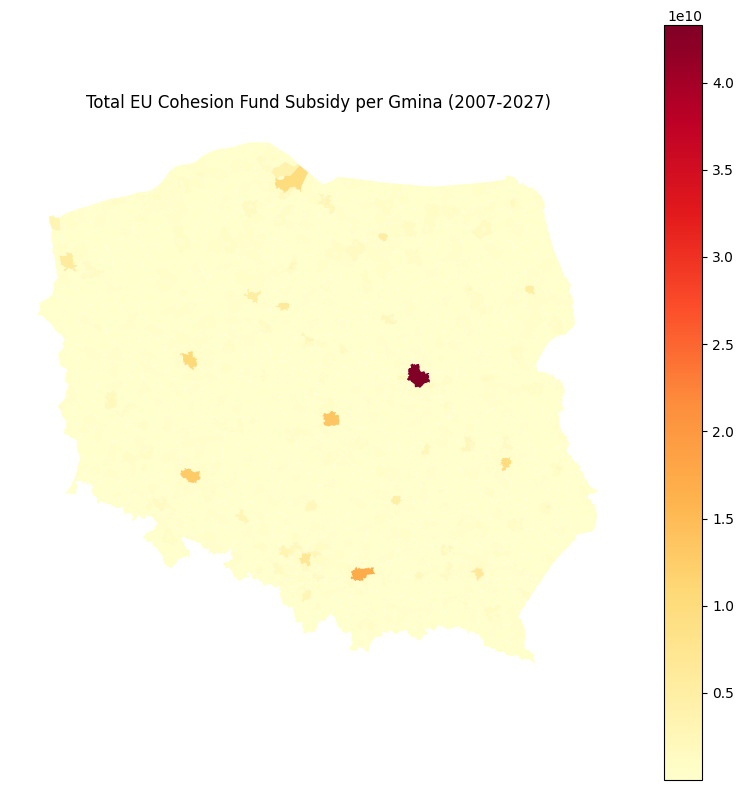

In [20]:
import geopandas as gpd
import pandas as pd 
import matplotlib.pyplot as plt

gminy_shp = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\gminy\gminy.shp")

# Total EU funding per gmina (all years, all periods)
agg = master.groupby('gmina_id')['EU_subsidy_PLN'].sum().reset_index()
agg['gmina_id'] = agg['gmina_id'].astype(str).str.zfill(7)
gminy_shp['JPT_KOD_JE'] = gminy_shp['JPT_KOD_JE'].astype(str).str.zfill(7)
agg['gmina_id_6'] = agg['gmina_id'].str[:6]
gminy_shp['gmina_id_6'] = gminy_shp['JPT_KOD_JE'].str[:6]

merged = gminy_shp.merge(agg, on='gmina_id_6', how='left')

print(f"Matched: {merged['EU_subsidy_PLN'].notna().sum()}")
print(f"Unmatched: {merged['EU_subsidy_PLN'].isna().sum()}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
merged.plot(column='EU_subsidy_PLN', cmap='YlOrRd', legend=True, ax=ax,
            missing_kwds={'color': 'lightgrey'})
ax.set_title('Total EU Cohesion Fund Subsidy per Gmina (2007-2027)')
ax.axis('off')
plt.tight_layout()
plt.show()



In [21]:
# DEBUG: check merge
print(f"Shapefile gminas: {gminy_shp['JPT_KOD_JE'].nunique()}")
print(f"Panel gminas: {agg['gmina_id'].nunique()}")
print(f"Matched (non-null): {merged['EU_subsidy_PLN'].notna().sum()}")
print(f"Unmatched (gray): {merged['EU_subsidy_PLN'].isna().sum()}")

# Compare formats
print(f"\nShapefile sample IDs: {sorted(gminy_shp['JPT_KOD_JE'].unique())[:10]}")
print(f"Panel sample IDs: {sorted(agg['gmina_id'].unique())[:10]}")

# Check lengths
print(f"\nShapefile ID lengths: {gminy_shp['JPT_KOD_JE'].str.len().value_counts().to_dict()}")
print(f"Panel ID lengths: {agg['gmina_id'].str.len().value_counts().to_dict()}")

# Find unmatched shapefile IDs
unmatched_shp = set(gminy_shp['JPT_KOD_JE']) - set(agg['gmina_id'])
print(f"\nSample unmatched shapefile IDs: {sorted(list(unmatched_shp))[:10]}")

# Find unmatched panel IDs
unmatched_panel = set(agg['gmina_id']) - set(gminy_shp['JPT_KOD_JE'])
print(f"Sample unmatched panel IDs: {sorted(list(unmatched_panel))[:10]}")

Shapefile gminas: 2477
Panel gminas: 2481
Matched (non-null): 2477
Unmatched (gray): 0

Shapefile sample IDs: ['0201011', '0201022', '0201032', '0201043', '0201052', '0201062', '0202011', '0202021', '0202033', '0202041']
Panel sample IDs: ['0201011', '0201022', '0201032', '0201043', '0201052', '0201062', '0202011', '0202021', '0202033', '0202041']

Shapefile ID lengths: {7: 2477}
Panel ID lengths: {7: 2481}

Sample unmatched shapefile IDs: ['0218032', '0408022', '0408052', '0419022', '0601112', '0602142', '0614052', '0614062', '0614102', '0615032']
Sample unmatched panel IDs: ['0218033', '0408023', '0408053', '0419023', '0601113', '0602143', '0614053', '0614063', '0614103', '0615033']


In [22]:
# Find them in the panel
for name, code6 in [('Biała Podlaska', '066101'), ('Zielona Góra', '086201')]:
    matches = agg[agg['gmina_id'].str.contains('0661|0862')]
    print(f"{name} ({code6}): {matches['gmina_id'].values}")

Biała Podlaska (066101): ['0661011' '0862011']
Zielona Góra (086201): ['0661011' '0862011']


## 12. Merging with Other Datasets

### With BDL panel data:

In [23]:
# bdl = pd.read_csv(PATH(OUTPUT_DIR)'bdl_gmina_panel.csv')
# bdl['gmina_id'] = bdl['unit_id'].astype(str).str[:7]
# merged = bdl.merge(master, on=['gmina_id', 'Year'], how='left', suffixes=('', '_eu'))
# merged['EU_subsidy_PLN'] = merged['EU_subsidy_PLN'].fillna(0)


### With marginalizacja status:
```python
marg = pd.read_csv('marginalizacja_list_755_with_historical_flags.csv')
marg['gmina_id'] = marg['teryt_6digit'].astype(str).str.zfill(6) + '0'  # 6→7 digit approx
merged = master.merge(marg[['gmina_id', 'marginalizacja_2021_2027']], on='gmina_id', how='left')
```

### With electoral data (PKW):
```python
pkw = pd.read_csv('your_pkw_data.csv')
# Match on TERYT gmina code — verify format (6 vs 7 digit)
```